Relationship between convective power and magnetic energy 
=====
***

In [3]:
using Plots
using Distributions
using StatsBase
using DelimitedFiles
using Interpolations

Constants

In [5]:
kyr = 1.0e3
mT = 1.0e-3
TW = 1.0e12;

pscale = 1.015e8; # convert power density to total power in TW 
tscale = 45963;  # years
sectoyear = 365.25 * 24 * 60 * 60

# geometry 
b = 3.48e6
c = 1.22e6
L = b - c
V = 4 * pi * (b^3 - c^3)/3

# physical properties
ρ = 1.1e4
ν = L^2 / (tscale * sectoyear)
μ = 4 * π * 1.0e-7
Ω_true = 0.7292e-4;
vscale = ν/L

# dimensionless constants
Ek = 3e-5  # Ekman
Pm = 5;
η = ν/Pm
Ω = ν / (Ek * L^2)
bscale = sqrt(ρ * μ * η * Ω_true)

0.000842542611260317

Read total convective power

In [7]:
data = readdlm("power1.dat")
tp = (data[:,1].-data[1,1]) * tscale/kyr;
p = (data[:,2]/pscale);    # in TW

pnd = data[:,2]

# remove redundant elements
deleteat!(tp,8030:8179)
deleteat!(p,8030:8179)
deleteat!(pnd,8030:8179)

ndata_in = length(tp)

47944

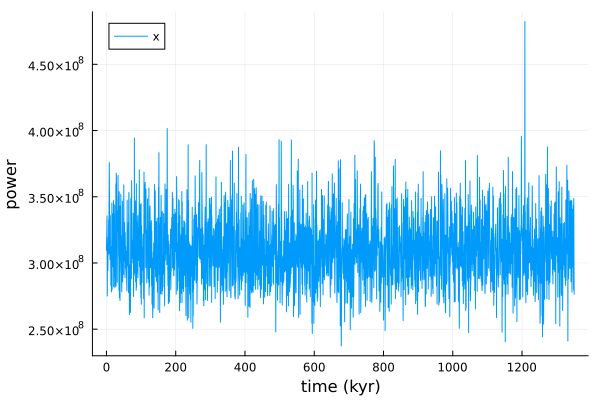

In [8]:
idecimate = 20;
plot(tp[1:idecimate:end],pnd[1:idecimate:end],
    xlabel="time (kyr)",
    ylabel="power",label="x")

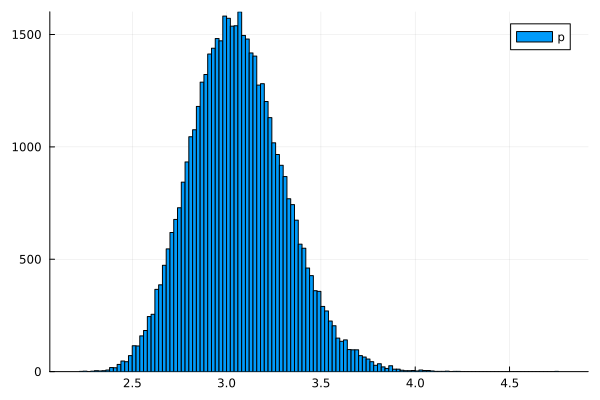

In [9]:
histogram(p,label="p")

In [10]:
println("mean = ",mean(p)," TW",'\n',"std = ",std(p)," TW",'\n',"skewness = ",skewness(p))

mean = 3.0601085109653794 TW
std = 0.24704028095938962 TW
skewness = 0.29725547616793385


In [11]:
# Interpolate onto a uniform time grid
dt =  tp[end]/ndata_in
tpinp = (0.0 : dt : tp[end]);
nodes = (tp,);
itp = interpolate(nodes,p,Gridded(Linear()));
pinp = itp(tpinp);
ndata = length(tpinp)

47945

Compute autocorrelation of uncorrected power 

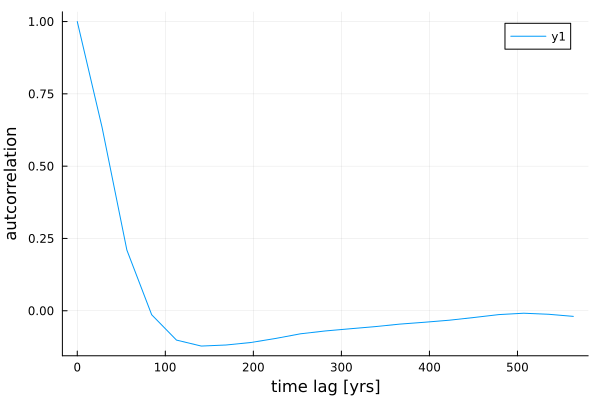

In [13]:
lag = (0 : 20)
c = autocor(pinp,lag,demean=true)
plot(lag * dt * kyr, c,
    xlabel="time lag [yrs]",
    ylabel="autcorrelation")

In [14]:
tau = 0.0;

for i = 1 : length(lag)-1
    tau = tau + 0.5*(c[i]+c[i+1])*dt
end
taup = lag[findfirst(y->y < exp(-1.0),c)]

print(" Integrated correlation time = " ,tau," kyr")
print("\n Point correlation time = ",taup*dt," kyr")

 Integrated correlation time = 0.009328230925170431 kyr
 Point correlation time = 0.056341343017609236 kyr

Read magnetic energy

In [16]:
data = readdlm("e_mag1.dat")
tb = (data[:,1].-data[1,1]) * tscale/kyr;
b2 = 2 * data[:,2] * Ek * Pm * bscale^2;


# remove redundant elements
deleteat!(tb,8030:8179)
deleteat!(b2,8030:8179)

m = b2 / (ρ * μ)
ndata_in

47944

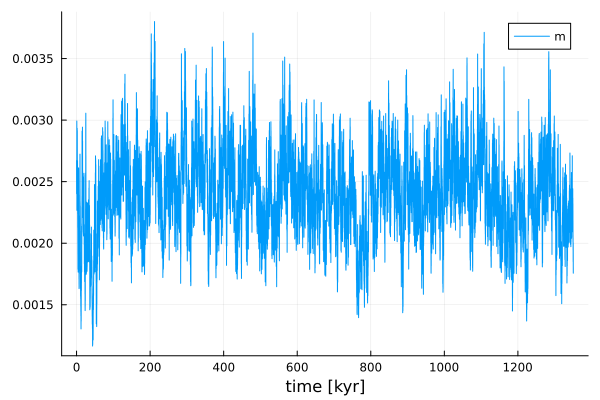

In [17]:
idecimate = 20;
plot(tb,m,label="m",xlabel="time [kyr]")

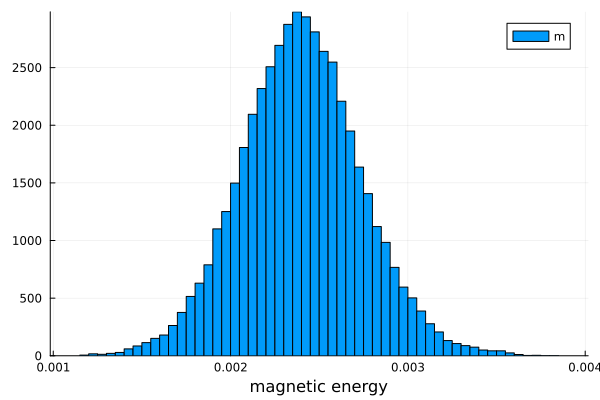

In [18]:
histogram(m,label="m",xlabel="magnetic energy")

In [19]:
println("mean = ",mean(m),'\n',
    "std = ",std(m),'\n',
    "skewness = ",skewness(m))

mean = 0.002396608088555573
std = 0.00033975409361310636
skewness = 0.08763452854996417


In [20]:
# Interpolate onto a uniform time grid
dt =  tb[end]/ndata_in; 
tbinp = (0.0 : dt : tb[end]);
nodes = (tb,);
itp = interpolate(nodes,m,Gridded(Linear()));
m_inp = itp(tbinp);
ndata = length(tbinp)

47945

In [21]:
data = readdlm("e_kin1.dat")
tv = (data[:,1].-data[1,1]) * tscale/kyr;
v2 = 2*data[:,2];
ke_nd = data[:,2];

# remove redundant elements
deleteat!(tv,8030:8179)
deleteat!(v2,8030:8179)

v = sqrt.(v2) * vscale
ndata_in = length(tv)
println("Overturn time = ",(L/mean(v))/sectoyear," yr")

Overturn time = 130.55871692571876 yr


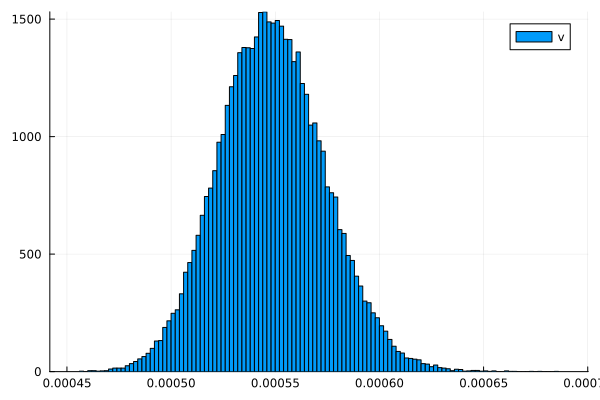

In [22]:
histogram(v,label="v")

In [23]:
# Interpolate onto a uniform time grid
dt =  tv[end]/ndata_in;
tvinp = (0.0 : dt : tv[end]);
nodes = (tv,);
itp = interpolate(nodes,v,Gridded(Linear()));
vinp = itp(tvinp);
ndata = length(tvinp)

47945